莊俊明 ： 2 分，學習時間： 20 小時，出勤率： 68 %，睡眠時間： 4 小時，社交活動： high
-----------
葉俊廷 ： 14 分，學習時間： 31 小時，出勤率： 84 %，睡眠時間： 4 小時，社交活動： high
-----------
潘志鴻 ： 79 分，學習時間： 15 小時，出勤率： 79 %，睡眠時間： 9 小時，社交活動： medium
-----------
劉武雄 ： 26 分，學習時間： 23 小時，出勤率： 99 %，睡眠時間： 9 小時，社交活動： low
-----------
唐志豪 ： 63 分，學習時間： 13 小時，出勤率： 74 %，睡眠時間： 4 小時，社交活動： high
-----------
林雅婷 ： 15 分，學習時間： 31 小時，出勤率： 70 %，睡眠時間： 5 小時，社交活動： high
-----------
沈麗珠 ： 53 分，學習時間： 19 小時，出勤率： 84 %，睡眠時間： 8 小時，社交活動： medium
-----------
詹美鳳 ： 92 分，學習時間： 14 小時，出勤率： 91 %，睡眠時間： 7 小時，社交活動： high
-----------
翁明宗 ： 79 分，學習時間： 39 小時，出勤率： 100 %，睡眠時間： 9 小時，社交活動： medium
-----------
蘇雅萍 ： 85 分，學習時間： 9 小時，出勤率： 89 %，睡眠時間： 5 小時，社交活動： low
-----------
陳雅雯 ： 77 分，學習時間： 28 小時，出勤率： 75 %，睡眠時間： 4 小時，社交活動： medium
-----------
張凱翔 ： 10 分，學習時間： 9 小時，出勤率： 97 %，睡眠時間： 8 小時，社交活動： medium
-----------
周碧雲 ： 56 分，學習時間： 29 小時，出勤率： 79 %，睡眠時間： 5 小時，社交活動： high
-----------
田俊良 ： 97 分，學習時間： 9 小時，出勤率： 61 %，睡眠時間： 7 小時，社交活動： high
-----------
周雅萍 ： 45 分，學習時間： 39 小時，出勤率： 82 %，睡眠時間： 7 小時，社交活動： high
--

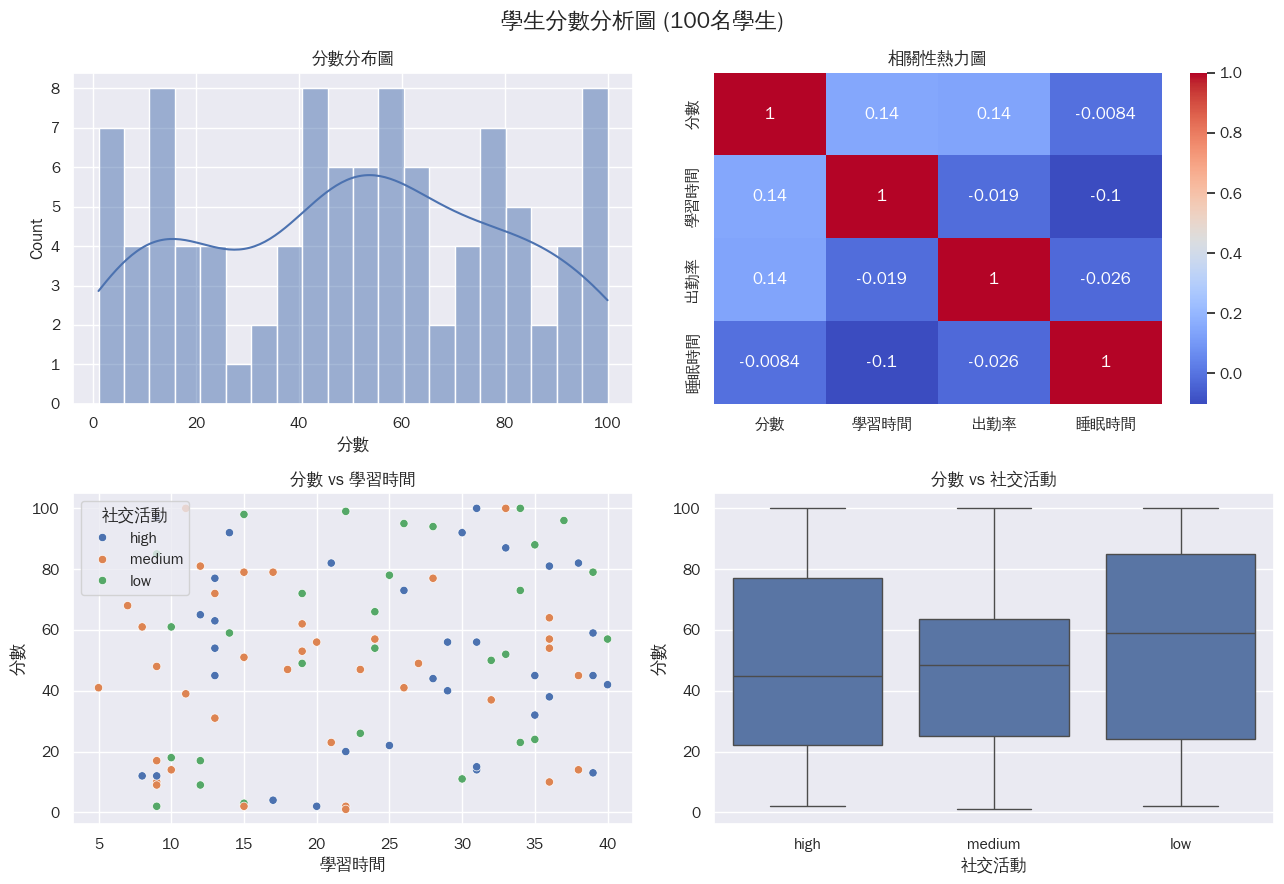

In [28]:
import pip
try:
    from faker import Faker
except ImportError:
    %pip install faker
    from faker import Faker

import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm

# 1. 安裝文泉驛正黑體
!apt-get -qq -y install fonts-wqy-zenhei

# 2. 直接指定字體檔案路徑並註冊到 Matplotlib
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
    plt.rcParams['font.family'] = font_name
    sns.set_theme(style="darkgrid", font=font_name)
else:
    print("找不到字體檔案，請檢查安裝路徑。")

plt.rcParams['axes.unicode_minus'] = False

fake = Faker('zh_TW')
data_list = []
scores = []

def task1():
    data_list.clear()
    scores.clear()
    for i in range(100):
        name = fake.name()
        sleep = random.randint(4, 9)
        attendance = random.randint(60, 100)
        study = random.randint(5, 40)
        score = random.randint(0, 100)
        social = random.choice(["low", "medium", "high"])

        scores.append(score)
        data_list.append({
            "姓名": name,
            "分數": score,
            "學習時間": study,
            "出勤率": attendance,
            "睡眠時間": sleep,
            "社交活動": social
        })
        # 依據您的要求列印每一筆資料
        print(f"{name} ： {score} 分，學習時間： {study} 小時，出勤率： {attendance} %，睡眠時間： {sleep} 小時，社交活動： {social}")
        print("-----------")

task1()

df = pd.DataFrame(data_list)

# 計算統計數據
avg_score = np.mean(scores)
print(f"樣本數： {len(scores)} 人 ,最高分： {max(scores)} 分 ,最低分： {min(scores)} 分 ,全班平均分數： {avg_score:.2f} 分 ,分數標準差： {np.std(scores, ddof=1):.2f} 分")

# 繪製圖表
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("學生分數分析圖 (100名學生)", fontsize=16, fontweight='bold')

sns.histplot(df["分數"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("分數分布圖")

numeric_cols = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("相關性熱力圖")

sns.scatterplot(data=df, x="學習時間", y="分數", hue="社交活動", ax=axes[1, 0])
axes[1, 0].set_title("分數 vs 學習時間")

sns.boxplot(data=df, x="社交活動", y="分數", ax=axes[1, 1])
axes[1, 1].set_title("分數 vs 社交活動")

plt.tight_layout()
plt.show()